In [1]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [2]:
ssplist = ["126","245","370","585"]

In [3]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
historical_era = [1960,2000]
tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1950,2080]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [35]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)


data/MPI_annualmean_126_tos.pkl
data/MPI_annualmean_245_tos.pkl
data/MPI_annualmean_370_tos.pkl
data/MPI_annualmean_585_tos.pkl


In [36]:
# plt.subplot(1,1,1)
allpred = []

for iseed, seed in enumerate(seedlist):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era,inputlength,outputavgtime, tpercentile, latsel, lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)
    outputtestclass = np.argmax(outputtest.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt
    nullval,nulltest = AllData.calculate_nulls(trainvaltest)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+filefront+"avgtime"+str(outputavgtime)+"_allssps_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True,map_location=torch.device('cpu')) )
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)
        predtest = cnn(inputtest, inputtestGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())

    predtestclass = torch.argmax(predtest, dim=1).numpy()

    acc = np.mean(predvalclass == outputvalclass)
    acctest = np.mean(predtestclass == outputtestclass)
    gmtacc = np.mean(nullval == outputvalclass)

    gmttestacc = np.mean(nulltest == outputtestclass)

    print("Seed ", str(seed), " val accuracy: ", str(acc))
    print("Seed ", str(seed), " gmt val accuracy: ", str(gmtacc))

    print("Seed ", str(seed), " test accuracy: ", str(acctest))
    print("Seed ", str(seed), " gmt test accuracy: ", str(gmttestacc))
    # predseed = allpred[iseed]
    # predseed = np.argmax(predseed, axis=1)
    # predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    # predseedmean = np.mean(predseed, axis=0)
    # plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

# plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
# plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

# gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
# print("GMT only val accuracy: ", str(gmtonlyacc))

# plt.xlim(2000,2040)


Seed  62469869  val accuracy:  0.7880230518667001
Seed  62469869  gmt val accuracy:  0.7930343272362816
Seed  62469869  test accuracy:  0.7923452768729642
Seed  62469869  gmt test accuracy:  0.7869163952225842
Seed  71856281  val accuracy:  0.80706589827111
Seed  71856281  gmt val accuracy:  0.7930343272362816
Seed  71856281  test accuracy:  0.7893593919652552
Seed  71856281  gmt test accuracy:  0.7934310532030402
Seed  47621498  val accuracy:  0.7962916562265097
Seed  47621498  gmt val accuracy:  0.8140816837885242
Seed  47621498  test accuracy:  0.7904451682953312
Seed  47621498  gmt test accuracy:  0.7858306188925082
Seed  10431957  val accuracy:  0.7800050112753696
Seed  10431957  gmt val accuracy:  0.7880230518667001
Seed  10431957  test accuracy:  0.7899022801302932
Seed  10431957  gmt test accuracy:  0.7928881650380022
Seed  50561320  val accuracy:  0.7945377098471561
Seed  50561320  gmt val accuracy:  0.8055625156602355
Seed  50561320  test accuracy:  0.7890879478827362
Seed  5

In [ ]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

array([293.48633667, 292.25887951, 292.76544573, 293.33905178,
       293.01911923, 292.79637693, 293.03662386, 292.412165  ,
       293.10819194, 292.55537964, 293.16006176, 292.98244166,
       293.15600141, 292.86909015, 293.05302519, 293.03854275,
       294.11320171, 292.54505757, 292.79528499, 292.82292994,
       292.05307669, 293.2560739 , 293.17566679, 293.10524354,
       292.8987084 , 292.56994398, 292.32630407, 292.81228995,
       292.80175289, 292.86265131, 292.81146081, 292.98222945,
       293.35687337, 292.63056099, 293.22163292, 292.8182339 ,
       292.49013399, 293.06041777, 292.8569924 , 293.55210903,
       292.37282791, 293.0726079 , 293.22360882, 294.0299316 ,
       292.54924845, 292.93409874, 293.70172388, 292.62482658,
       292.79537195, 292.5713467 ])

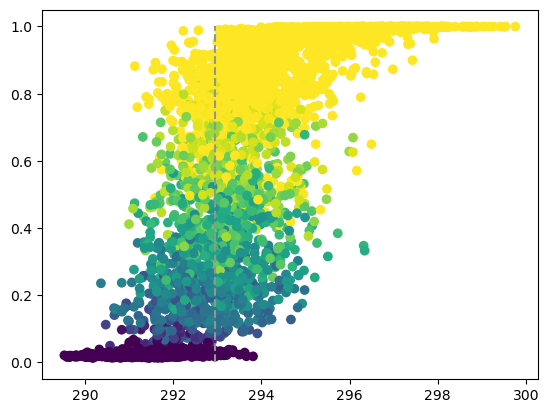

In [42]:
plt.scatter(allsummer,allpred[0][:,1],c=inputvalGMT.numpy(),vmin=0.3,vmax=1)
plt.vlines(np.mean(AllData.onesigmas),0,1,color='xkcd:grey',linestyle='dashed')

In [11]:
AllData.onesigmas.shape

(50,)

In [18]:
AllData.truesummer[2].shape

(50, 63)

In [27]:
allnull.shape

(3991,)

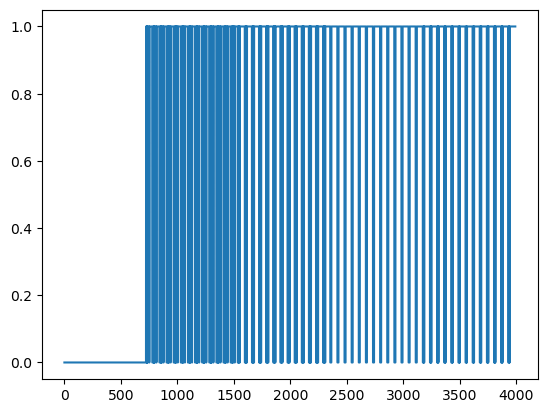

In [28]:
plt.plot(allnull)